# Exploratory Data Analysis (EDA)
## E-commerce Online Retail — 2009–2011

**Project:** Cohort Analysis & Time Series Forecasting for LTV/ROMI Optimization  
**Dataset:** `online_retail_cleaned_full.csv` (~798K transactions, 5,362 customers)  
**Period:** December 2009 – December 2011

---

### Nội dung phân tích

| # | Section |
|---|--------|
| 1 | Setup & Data Loading |
| 2 | Tổng quan dữ liệu (Overview) |
| 3 | Phân tích đơn biến (Univariate) |
| 4 | Phân tích doanh thu theo thời gian (Time Series) |
| 5 | Phân tích khách hàng & RFM |
| 6 | Phân tích sản phẩm |
| 7 | Phân tích địa lý (Geographic) |
| 8 | Phân tích hàng trả (Returns) |
| 9 | Cohort Preview |
| 10 | Key Insights |

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Plotting theme ──────────────────────────────────────────────────────────
PALETTE   = 'husl'
BG_COLOR  = '#F8F9FA'
ACCENT    = '#2196F3'
ACCENT2   = '#FF5722'

sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor'  : BG_COLOR,
    'figure.dpi'      : 110,
})

# ── Pandas display ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('✅  Libraries ready')

✅  Libraries ready


In [2]:
DATA_PATH = 'data/cleaned/online_retail_cleaned_full.csv'

df = pd.read_csv(
    DATA_PATH,
    parse_dates=['InvoiceDate', 'FirstPurchaseDate'],
    dtype={'Invoice': str, 'StockCode': str, 'Customer ID': str}
)

# Convenience splits
df_sales   = df[df['Quantity'] > 0].copy()
df_returns = df[df['Quantity'] < 0].copy()

print(f'Total rows     : {len(df):>10,}')
print(f'Sales rows     : {len(df_sales):>10,}')
print(f'Return rows    : {len(df_returns):>10,}')
print(f'Date range     : {df["InvoiceDate"].min().date()}  →  {df["InvoiceDate"].max().date()}')
print(f'Unique customers: {df["Customer ID"].nunique():>9,}')
print(f'Unique products : {df["StockCode"].nunique():>9,}')
print(f'Unique invoices : {df["Invoice"].nunique():>9,}')

Total rows     :    797,885
Sales rows     :    779,495
Return rows    :     18,390
Date range     : 2009-12-01  →  2011-12-09
Unique customers:     5,942
Unique products :     4,646
Unique invoices :    44,876


---
## 2. Tổng quan dữ liệu (Overview)

In [3]:
print('=== SCHEMA ===')
print(df.dtypes.to_string())
print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values 🎉')
print('\n=== DESCRIPTIVE STATISTICS (numeric) ===')
display(df.describe().T.style.format('{:,.2f}'))

=== SCHEMA ===
Invoice                          str
StockCode                        str
Description                      str
Quantity                       int64
InvoiceDate           datetime64[us]
Price                        float64
Customer ID                      str
Country                          str
IsReturn                        bool
TotalValue                   float64
Year                           int64
Month                          int64
Day                            int64
Hour                           int64
DayOfWeek                      int64
DayOfWeekName                    str
MonthYear                        str
Quarter                        int64
FirstPurchaseDate     datetime64[us]
CohortYear                     int64
CohortMonth                    int64
CohortQuarter                  int64
CohortMonthYear                  str
CohortIndex                    int64
PositiveQuantity               int64
PositiveTotalValue           float64
InvoiceType            

,count,mean,min,25%,50%,75%,max,std
Quantity,"797,885.00",12.60,"-80,995.00",2.00,5.00,12.00,"80,995.00",191.67
InvoiceDate,"797,885.00",",.2f",",.2f",",.2f",",.2f",",.2f",",.2f",nan
Price,"797,885.00",3.70,0.00,1.25,1.95,3.75,"38,970.00",71.39
TotalValue,"797,885.00",20.42,"-168,469.60",4.35,11.70,19.50,"168,469.60",313.52
Year,"797,885.00","2,010.43","2,009.00","2,010.00","2,010.00","2,011.00","2,011.00",0.57
Month,"797,885.00",7.41,1.00,5.00,8.00,10.00,12.00,3.42
Day,"797,885.00",15.39,1.00,8.00,15.00,23.00,31.00,8.66
Hour,"797,885.00",12.80,6.00,11.00,13.00,14.00,21.00,2.31
DayOfWeek,"797,885.00",2.63,0.00,1.00,2.00,4.00,6.00,1.94
Quarter,"797,885.00",2.80,1.00,2.00,3.00,4.00,4.00,1.13


In [4]:
# Key business KPIs
total_revenue  = df_sales['TotalValue'].sum()
total_returns  = abs(df_returns['TotalValue'].sum())
net_revenue    = total_revenue - total_returns
aov            = total_revenue / df_sales['Invoice'].nunique()
return_rate    = len(df_returns) / len(df) * 100

kpis = {
    'Gross Revenue (£)'       : f'{total_revenue:>14,.2f}',
    'Total Returns (£)'       : f'{total_returns:>14,.2f}',
    'Net Revenue (£)'         : f'{net_revenue:>14,.2f}',
    'Average Order Value (£)' : f'{aov:>14,.2f}',
    'Return Rate (%)'         : f'{return_rate:>14.2f}',
    'Unique Customers'        : f'{df["Customer ID"].nunique():>14,}',
    'Unique Products'         : f'{df["StockCode"].nunique():>14,}',
    'Unique Invoices'         : f'{df["Invoice"].nunique():>14,}',
}

print('═' * 40)
print('  KEY BUSINESS KPIs')
print('═' * 40)
for k, v in kpis.items():
    print(f'  {k:<28}: {v}')
print('═' * 40)

════════════════════════════════════════
  KEY BUSINESS KPIs
════════════════════════════════════════
  Gross Revenue (£)           :  17,374,804.27
  Total Returns (£)           :   1,084,812.98
  Net Revenue (£)             :  16,289,991.29
  Average Order Value (£)     :         469.91
  Return Rate (%)             :           2.30
  Unique Customers            :          5,942
  Unique Products             :          4,646
  Unique Invoices             :         44,876
════════════════════════════════════════


---
## 3. Phân tích đơn biến (Univariate Analysis)

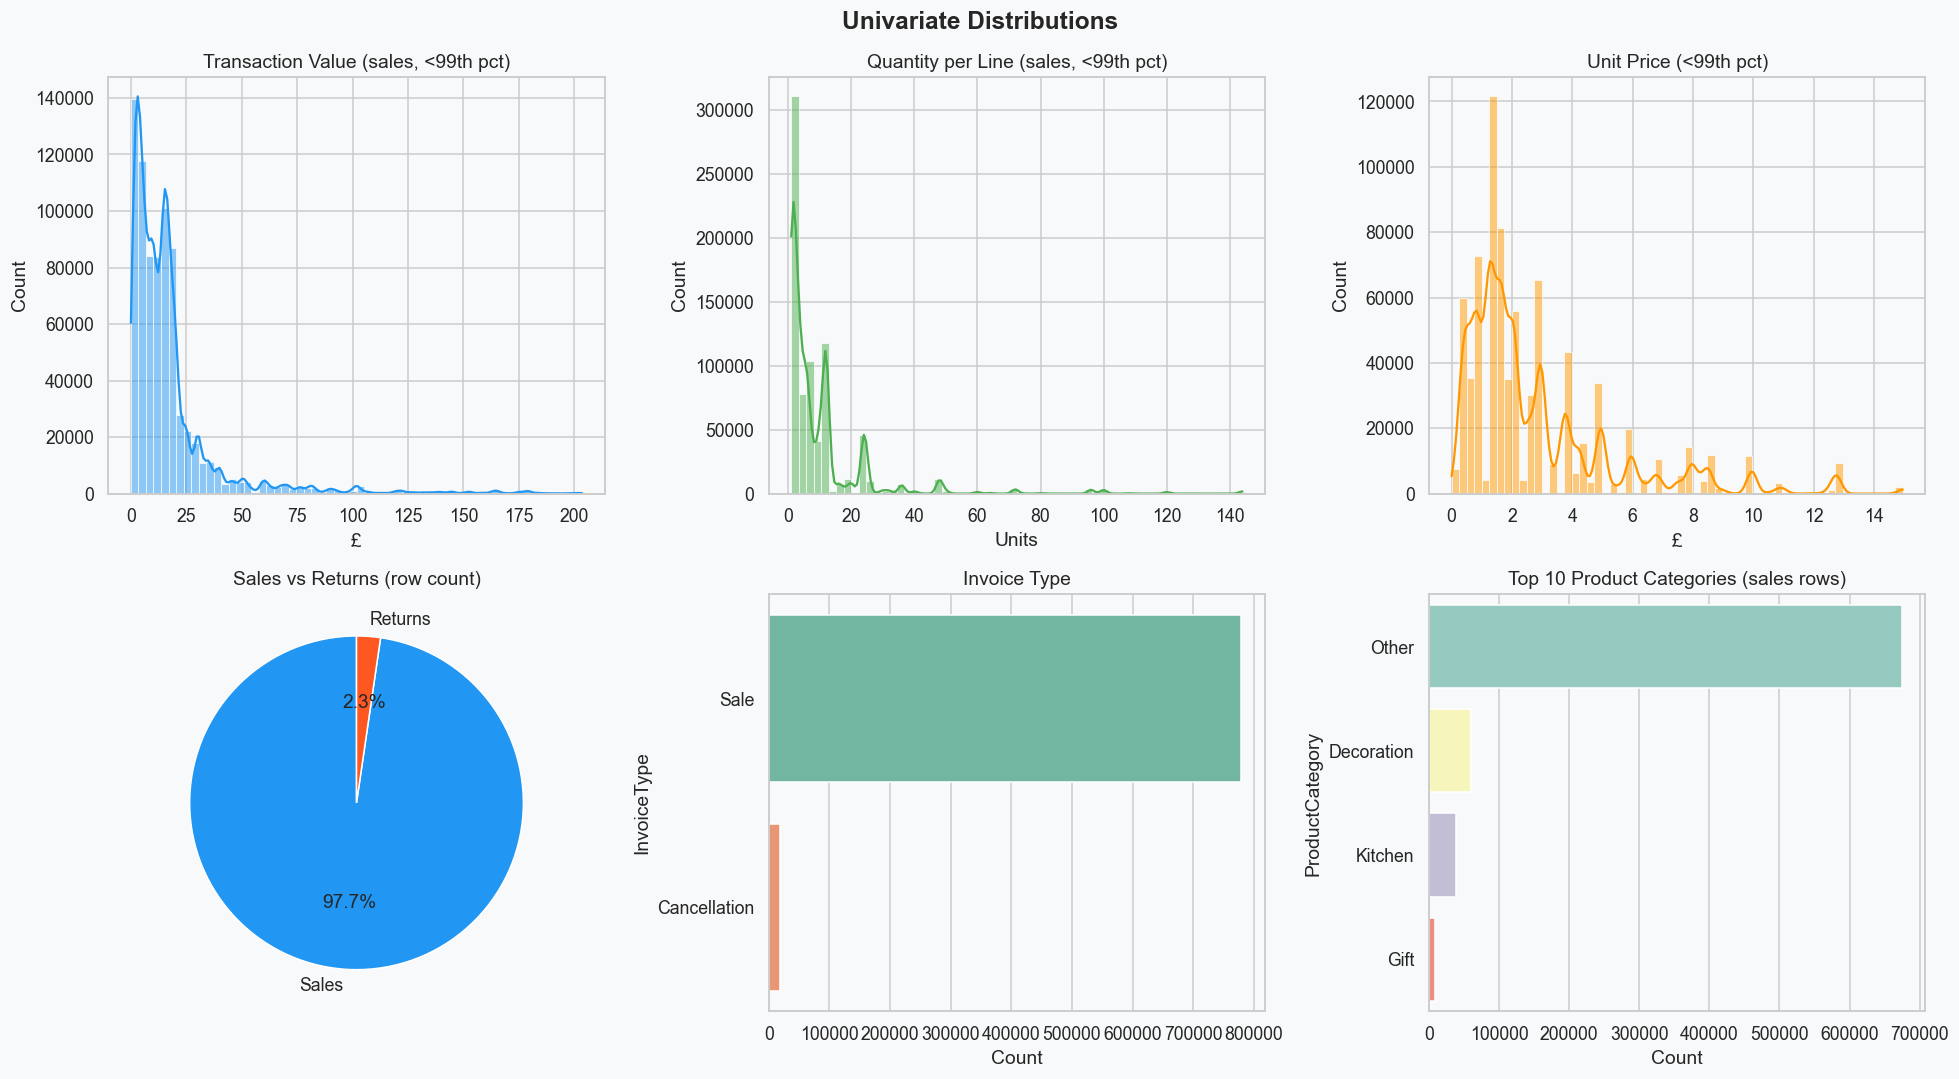

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Univariate Distributions', fontsize=16, fontweight='bold')

# 1. TotalValue (sales only, trim top 1%)
q99 = df_sales['TotalValue'].quantile(0.99)
sns.histplot(df_sales.loc[df_sales['TotalValue'] <= q99, 'TotalValue'],
             bins=60, kde=True, ax=axes[0,0], color=ACCENT)
axes[0,0].set_title('Transaction Value (sales, <99th pct)')
axes[0,0].set_xlabel('£')

# 2. Quantity (sales only, trim top 1%)
q99q = df_sales['Quantity'].quantile(0.99)
sns.histplot(df_sales.loc[df_sales['Quantity'] <= q99q, 'Quantity'],
             bins=60, kde=True, ax=axes[0,1], color='#4CAF50')
axes[0,1].set_title('Quantity per Line (sales, <99th pct)')
axes[0,1].set_xlabel('Units')

# 3. Price distribution
q99p = df['Price'].quantile(0.99)
sns.histplot(df.loc[df['Price'] <= q99p, 'Price'],
             bins=60, kde=True, ax=axes[0,2], color='#FF9800')
axes[0,2].set_title('Unit Price (<99th pct)')
axes[0,2].set_xlabel('£')

# 4. Sales vs Returns (pie)
counts = [len(df_sales), len(df_returns)]
axes[1,0].pie(counts, labels=['Sales', 'Returns'],
              autopct='%1.1f%%', colors=[ACCENT, ACCENT2],
              startangle=90, wedgeprops={'edgecolor':'white'})
axes[1,0].set_title('Sales vs Returns (row count)')

# 5. Invoice Type distribution
inv_counts = df['InvoiceType'].value_counts()
sns.barplot(x=inv_counts.values, y=inv_counts.index, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Invoice Type')
axes[1,1].set_xlabel('Count')

# 6. Product Category distribution
cat_counts = df_sales['ProductCategory'].value_counts().head(10)
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[1,2], palette='Set3')
axes[1,2].set_title('Top 10 Product Categories (sales rows)')
axes[1,2].set_xlabel('Count')

plt.tight_layout()
plt.show()

---
## 4. Phân tích doanh thu theo thời gian (Time Series Analysis)

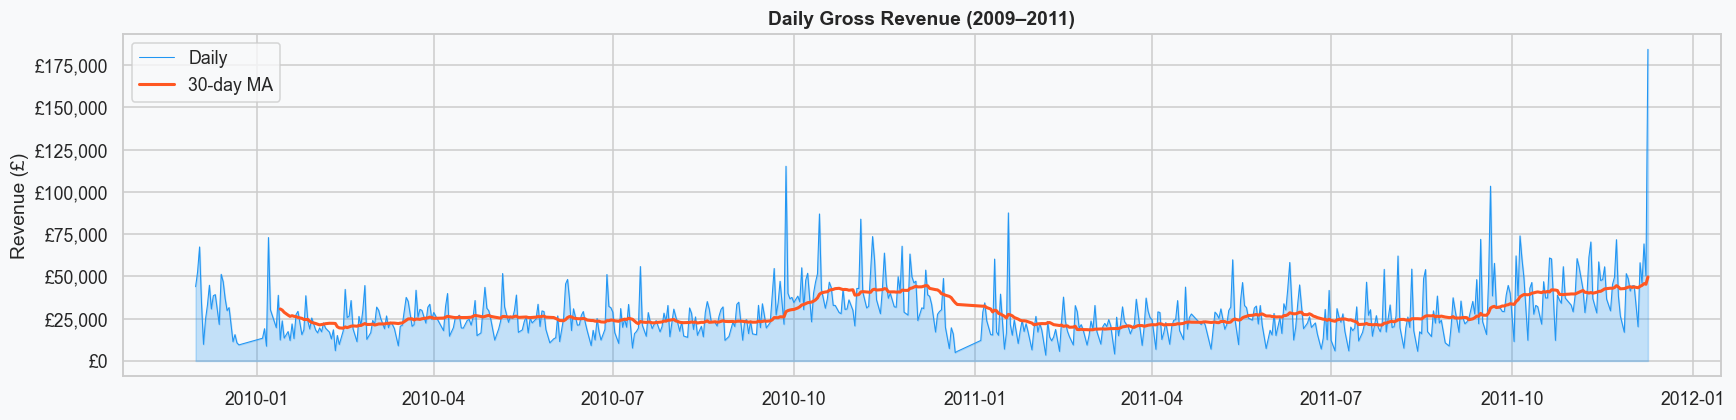

In [6]:
# ── 4.1 Daily revenue ────────────────────────────────────────────────────────
daily = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.date)['TotalValue']
    .sum()
    .reset_index()
    .rename(columns={'InvoiceDate': 'Date', 'TotalValue': 'Revenue'})
)
daily['Date'] = pd.to_datetime(daily['Date'])
daily['MA30']  = daily['Revenue'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(daily['Date'], daily['Revenue'], alpha=0.25, color=ACCENT)
ax.plot(daily['Date'], daily['Revenue'], linewidth=0.7, color=ACCENT, label='Daily')
ax.plot(daily['Date'], daily['MA30'], linewidth=2, color=ACCENT2, label='30-day MA')
ax.set_title('Daily Gross Revenue (2009–2011)', fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

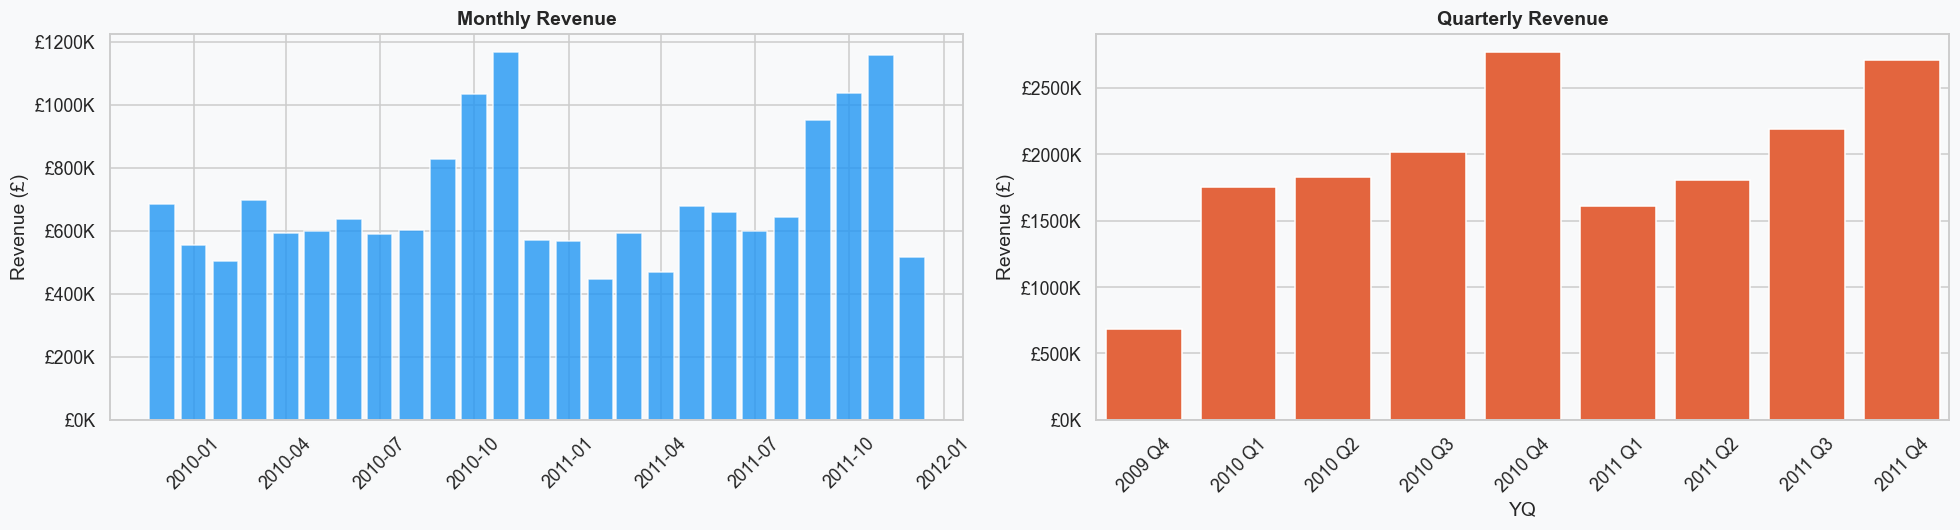

In [7]:
# ── 4.2 Monthly & Quarterly breakdown ────────────────────────────────────────
monthly = (
    df_sales.groupby(['Year', 'Month'])['TotalValue']
    .sum().reset_index()
)
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

quarterly = (
    df_sales.groupby(['Year', 'Quarter'])['TotalValue']
    .sum().reset_index()
)
quarterly['YQ'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(monthly['Date'], monthly['TotalValue'], width=25, color=ACCENT, alpha=0.8)
axes[0].set_title('Monthly Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=quarterly, x='YQ', y='TotalValue', ax=axes[1], color=ACCENT2)
axes[1].set_title('Quarterly Revenue', fontweight='bold')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

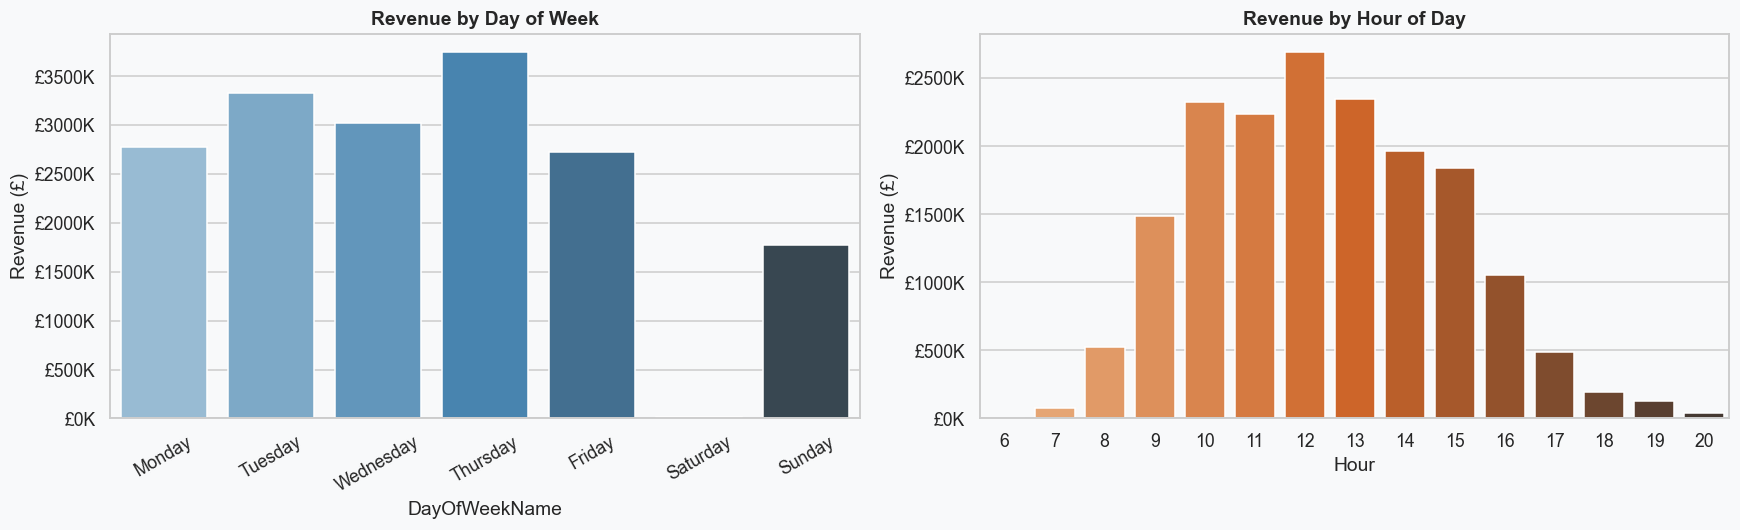

In [8]:
# ── 4.3 Day-of-week & Hour patterns ──────────────────────────────────────────
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev   = df_sales.groupby('DayOfWeekName')['TotalValue'].sum().reindex(dow_order)
hour_rev  = df_sales.groupby('Hour')['TotalValue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=dow_rev.index, y=dow_rev.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=hour_rev.index, y=hour_rev.values, ax=axes[1], palette='Oranges_d')
axes[1].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

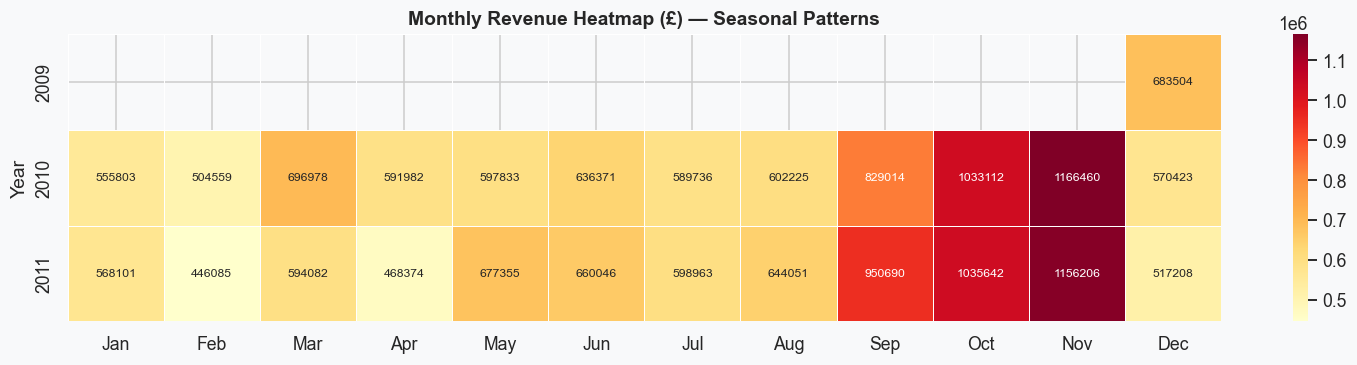

In [9]:
# ── 4.4 Monthly seasonality heatmap (Year × Month) ───────────────────────────
pivot_month = (
    df_sales.groupby(['Year', 'Month'])['TotalValue']
    .sum()
    .unstack('Month')
)
pivot_month.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(
    pivot_month, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Monthly Revenue Heatmap (£) — Seasonal Patterns', fontweight='bold')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

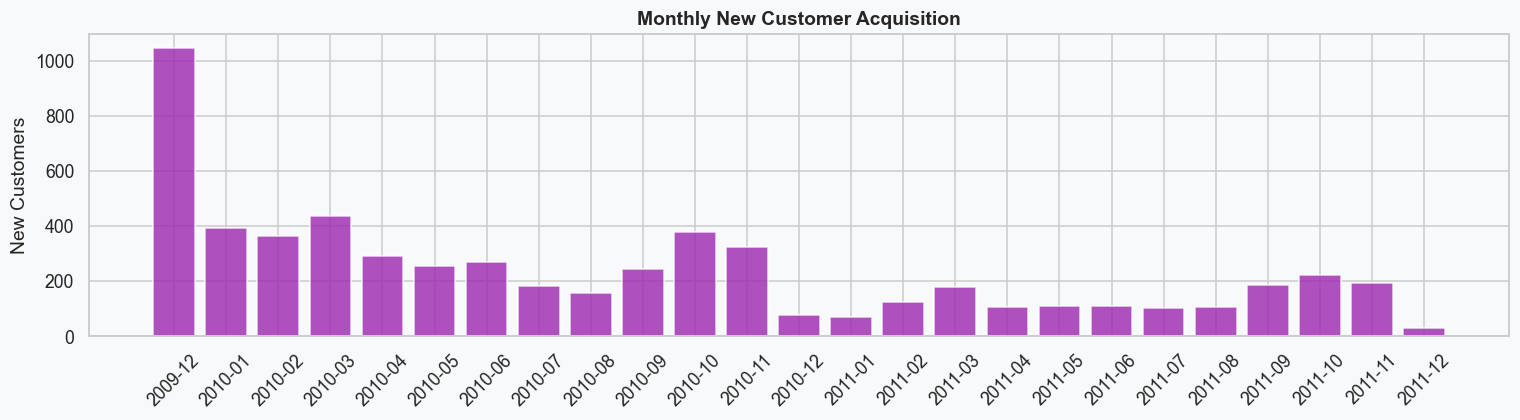

In [10]:
# ── 4.5 New customer acquisition over time ───────────────────────────────────
new_cust = (
    df.groupby(df['FirstPurchaseDate'].dt.to_period('M'))['Customer ID']
    .nunique()
    .reset_index()
    .rename(columns={'FirstPurchaseDate': 'Month', 'Customer ID': 'NewCustomers'})
)
new_cust['Month'] = new_cust['Month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(new_cust['Month'], new_cust['NewCustomers'], color='#9C27B0', alpha=0.8)
ax.set_title('Monthly New Customer Acquisition', fontweight='bold')
ax.set_ylabel('New Customers')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 5. Phân tích khách hàng & RFM

In [11]:
# ── 5.1 Build RFM table ──────────────────────────────────────────────────────
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = (
    df_sales.groupby('Customer ID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('Invoice',     'nunique'),
        Monetary  = ('TotalValue',  'sum'),
    )
    .reset_index()
)

# RFM quintile scoring (1=worst, 5=best)
rfm['R'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int)

def rfm_segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Churned'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print('RFM Summary:')
display(rfm[['Recency','Frequency','Monetary','RFM_Score']].describe().T)
print('\nSegment Distribution:')
print(rfm['Segment'].value_counts().to_string())

RFM Summary:


,count,mean,std,min,25%,50%,75%,max
Recency,"5,881.00",201.46,209.47,1.00,26.00,96.00,380.00,739.00
Frequency,"5,881.00",6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,"5,881.00","2,954.40","14,437.32",0.00,341.90,865.60,"2,247.72","580,987.04"
RFM_Score,"5,881.00",9.01,3.64,3.00,6.00,9.00,12.00,15.00



Segment Distribution:
Segment
Churned          1525
Champions        1482
Loyal            1222
At Risk           824
New Customers     444
Potential         384


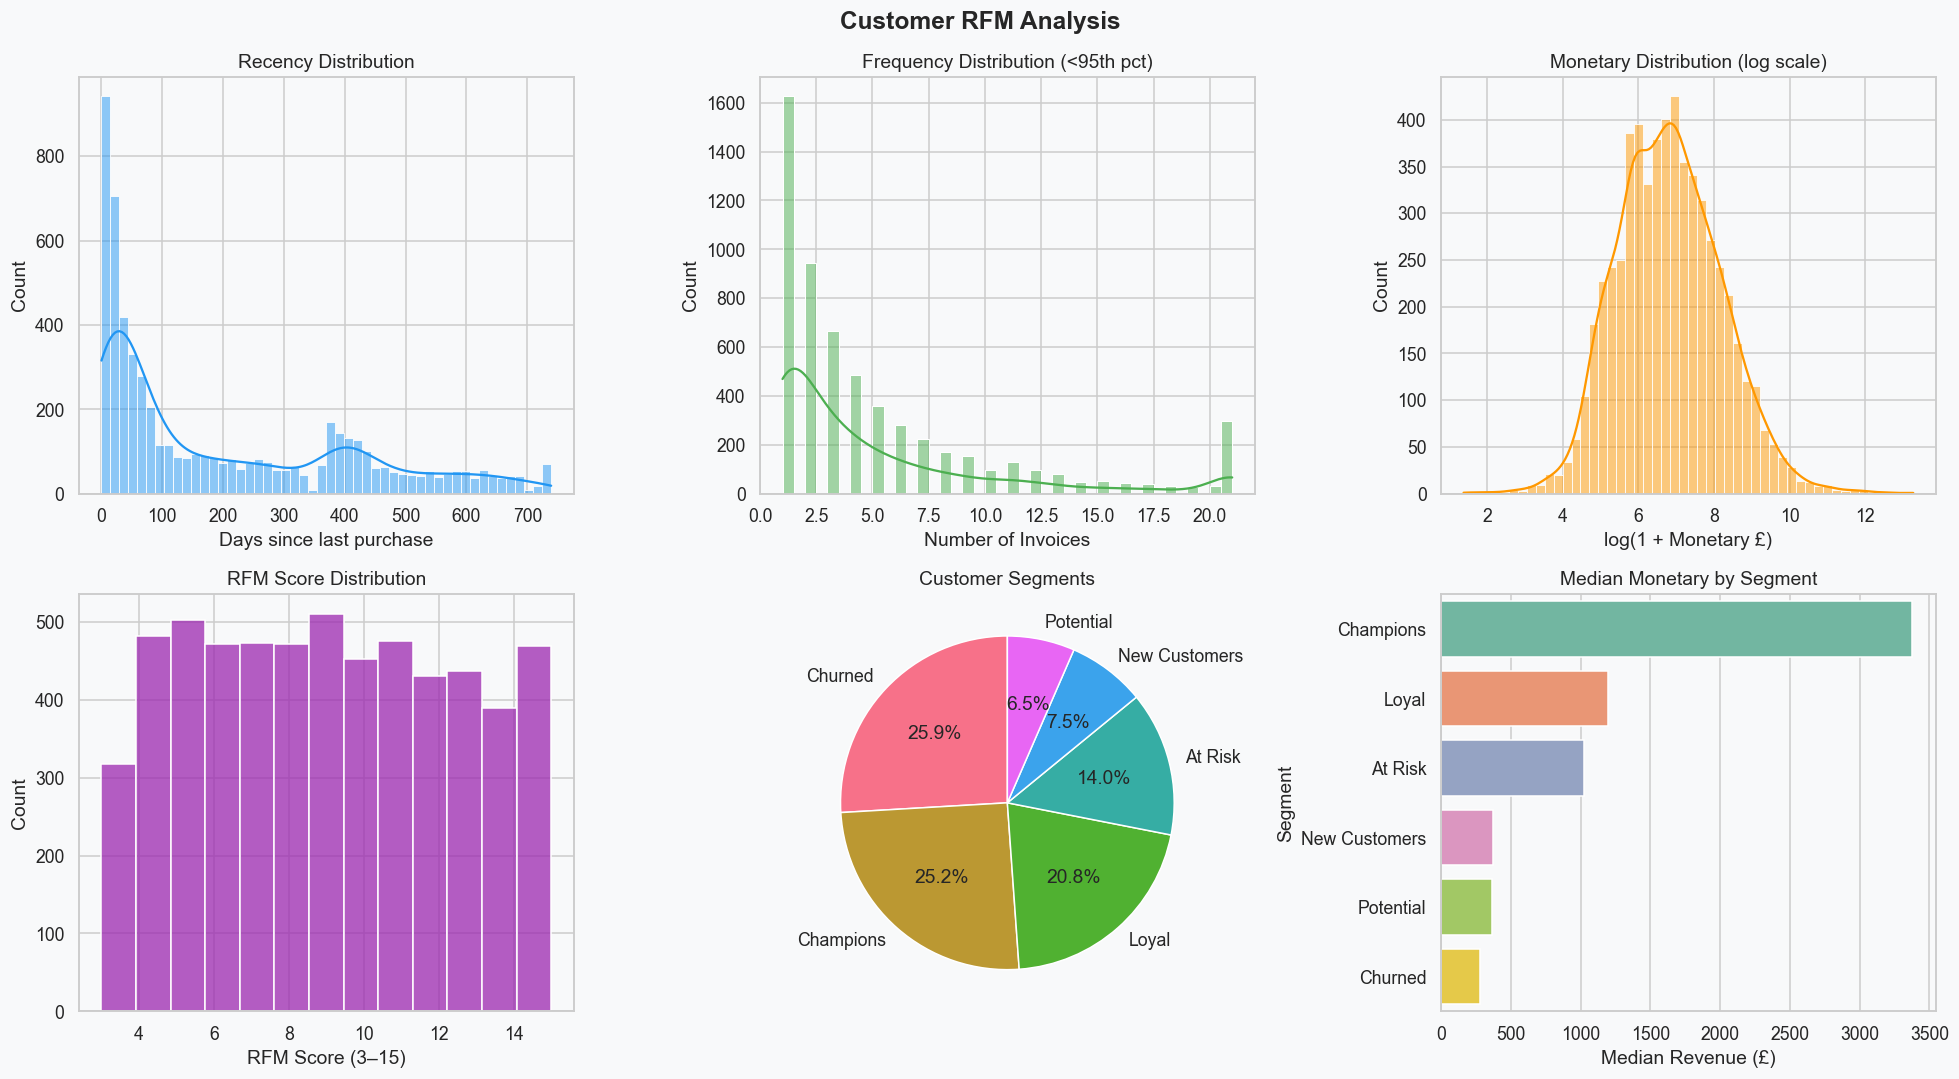

In [12]:
# ── 5.2 RFM Visualisations ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer RFM Analysis', fontsize=16, fontweight='bold')

# Recency distribution
sns.histplot(rfm['Recency'], bins=50, kde=True, ax=axes[0,0], color=ACCENT)
axes[0,0].set_title('Recency Distribution')
axes[0,0].set_xlabel('Days since last purchase')

# Frequency distribution (clip)
sns.histplot(rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.95)),
             bins=40, kde=True, ax=axes[0,1], color='#4CAF50')
axes[0,1].set_title('Frequency Distribution (<95th pct)')
axes[0,1].set_xlabel('Number of Invoices')

# Monetary distribution (log scale)
pos_monetary = rfm[rfm['Monetary'] > 0]['Monetary']
sns.histplot(np.log1p(pos_monetary), bins=50, kde=True, ax=axes[0,2], color='#FF9800')
axes[0,2].set_title('Monetary Distribution (log scale)')
axes[0,2].set_xlabel('log(1 + Monetary £)')

# RFM Score distribution
sns.histplot(rfm['RFM_Score'], bins=13, ax=axes[1,0], color='#9C27B0')
axes[1,0].set_title('RFM Score Distribution')
axes[1,0].set_xlabel('RFM Score (3–15)')

# Segment counts
seg_counts = rfm['Segment'].value_counts()
axes[1,1].pie(seg_counts.values, labels=seg_counts.index,
              autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor':'white'})
axes[1,1].set_title('Customer Segments')

# Segment avg Monetary
seg_monetary = rfm.groupby('Segment')['Monetary'].median().sort_values(ascending=False)
sns.barplot(x=seg_monetary.values, y=seg_monetary.index, ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Median Monetary by Segment')
axes[1,2].set_xlabel('Median Revenue (£)')

plt.tight_layout()
plt.show()

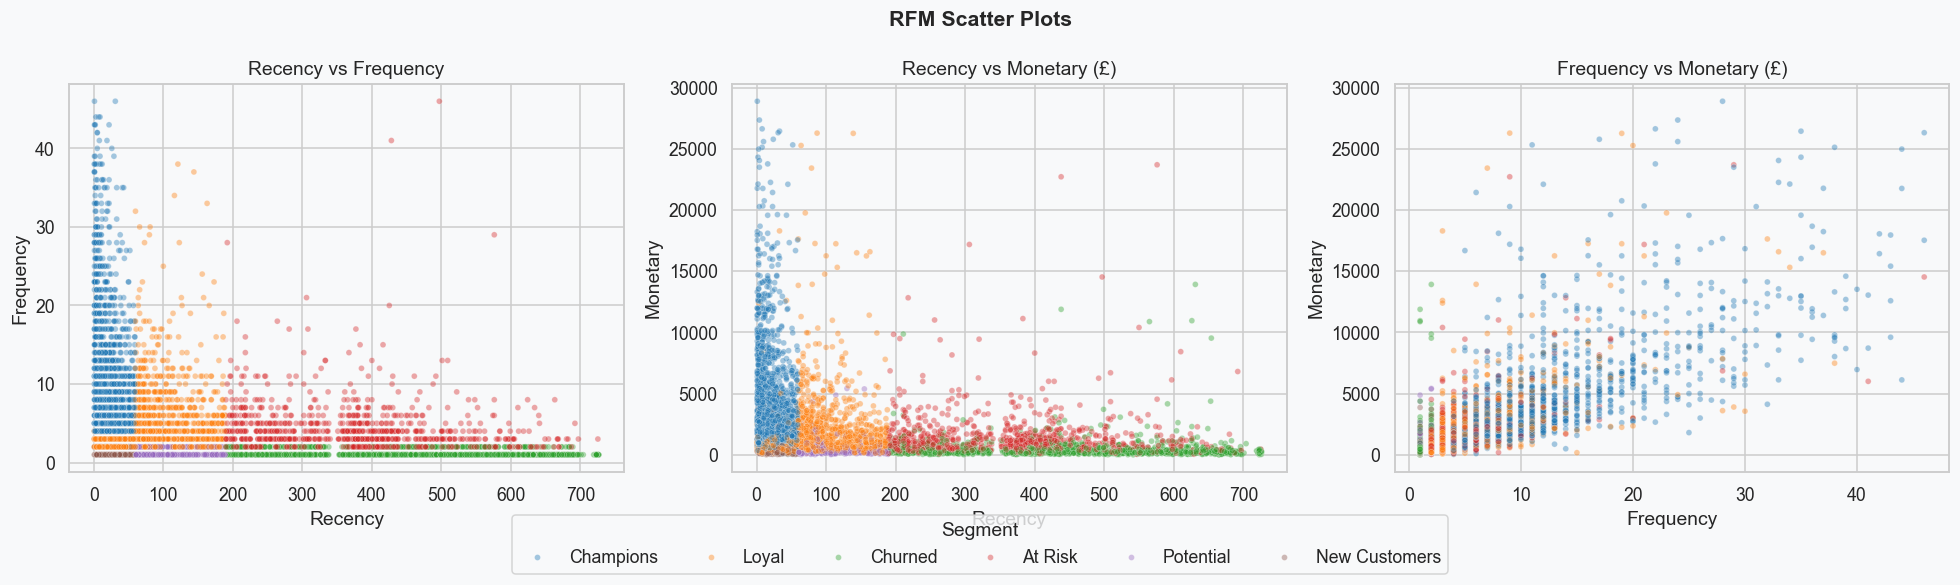

In [13]:
# ── 5.3 Recency–Frequency–Monetary scatter ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RFM Scatter Plots', fontsize=14, fontweight='bold')

# Clip for readability
r_cap = rfm['Recency'].quantile(0.99)
f_cap = rfm['Frequency'].quantile(0.99)
m_cap = rfm['Monetary'].quantile(0.99)
sample = rfm[(rfm['Recency']<=r_cap)&(rfm['Frequency']<=f_cap)&(rfm['Monetary']<=m_cap)]

scatter_kw = dict(alpha=0.4, s=15, hue='Segment', data=sample, palette='tab10')

sns.scatterplot(x='Recency',   y='Frequency', ax=axes[0], **scatter_kw)
axes[0].set_title('Recency vs Frequency')
axes[0].get_legend().remove()

sns.scatterplot(x='Recency',   y='Monetary',  ax=axes[1], **scatter_kw)
axes[1].set_title('Recency vs Monetary (£)')
axes[1].get_legend().remove()

sns.scatterplot(x='Frequency', y='Monetary',  ax=axes[2], **scatter_kw)
axes[2].set_title('Frequency vs Monetary (£)')
handles, labels = axes[2].get_legend_handles_labels()
axes[2].get_legend().remove()

fig.legend(handles, labels, title='Segment', loc='lower center',
           ncol=len(labels), bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

---
## 6. Phân tích sản phẩm (Product Analysis)

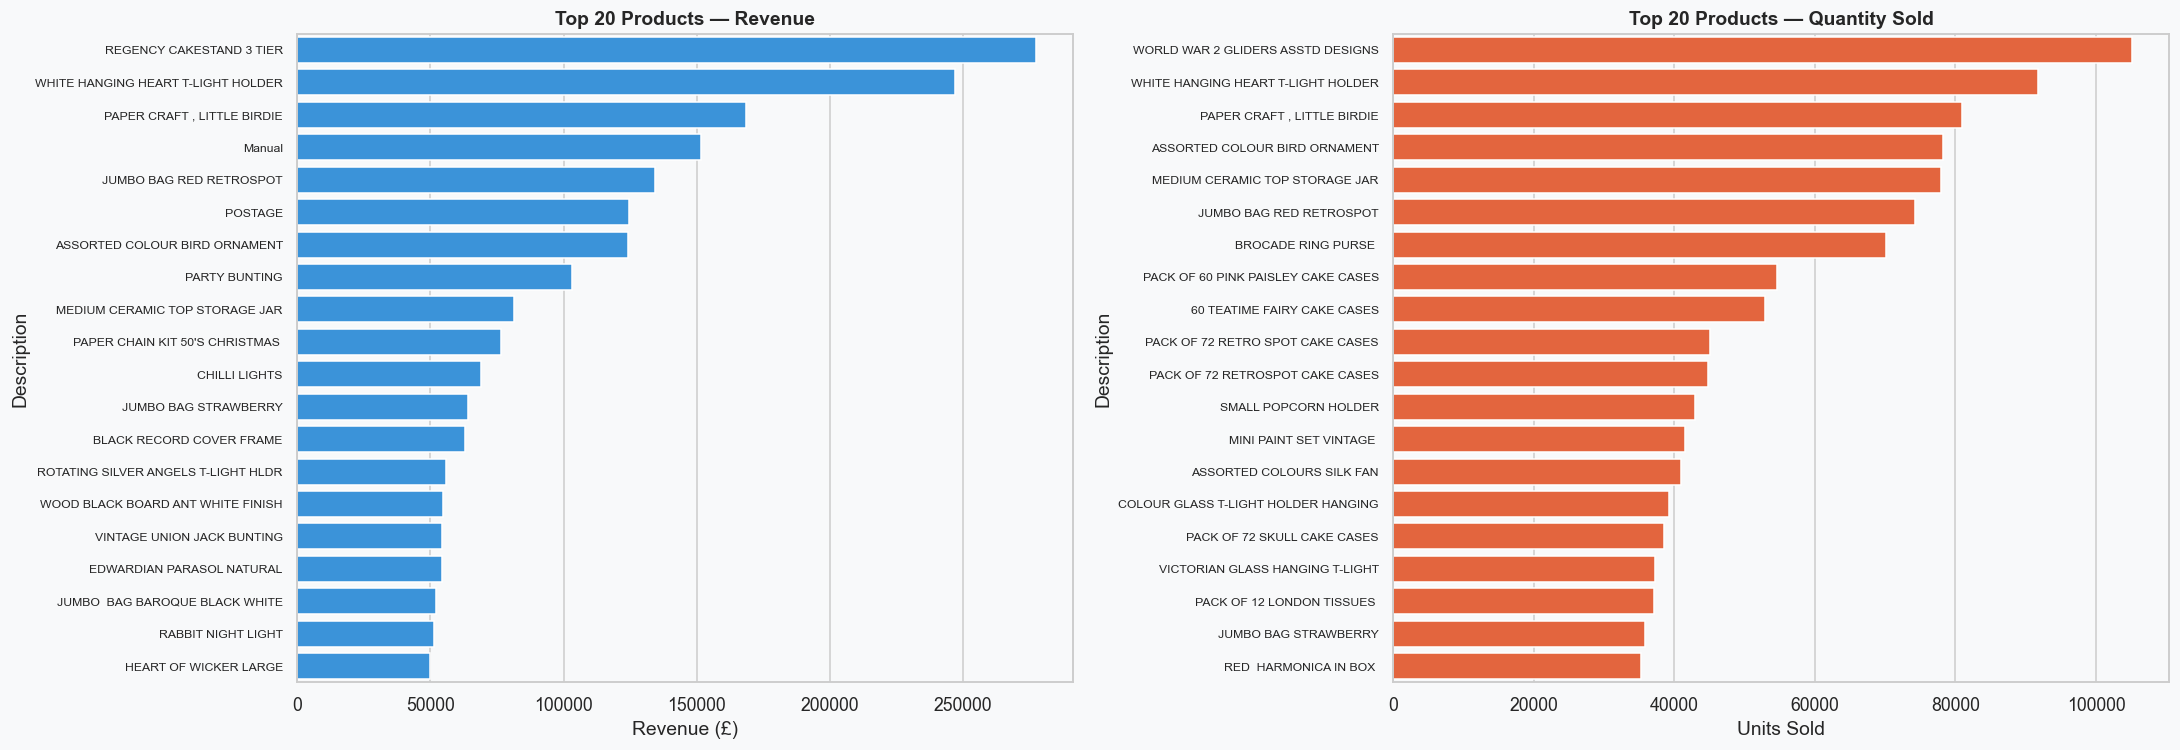


Top 10 Products by Revenue:


,Description,TotalRevenue,TotalQuantity,UniqueCustomers,AvgPrice
1862,REGENCY CAKESTAND 3 TIER,"277,656.25",24139,1314,12.45
4751,WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01",91757,1490,2.87
3283,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,2.08
5309,Manual,"151,777.67",9391,443,212.60
4725,JUMBO BAG RED RETROSPOT,"134,307.44",74224,860,1.97
5311,POSTAGE,"124,648.04",5235,405,29.94
4456,ASSORTED COLOUR BIRD ORNAMENT,"124,351.86",78234,1010,1.68
3627,PARTY BUNTING,"103,283.38",23464,894,4.77
2781,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,138,1.22
1449,PAPER CHAIN KIT 50'S CHRISTMAS,"76,598.18",28380,896,2.92


In [14]:
# ── 6.1 Top 20 products by revenue & quantity ────────────────────────────────
product_stats = (
    df_sales.groupby(['StockCode','Description'])
    .agg(
        TotalRevenue    = ('TotalValue', 'sum'),
        TotalQuantity   = ('Quantity',   'sum'),
        UniqueCustomers = ('Customer ID','nunique'),
        AvgPrice        = ('Price',      'mean'),
    )
    .reset_index()
    .sort_values('TotalRevenue', ascending=False)
)

top20_rev = product_stats.head(20)
top20_qty = product_stats.nlargest(20, 'TotalQuantity')

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.barplot(data=top20_rev, x='TotalRevenue',    y='Description', ax=axes[0], color=ACCENT)
axes[0].set_title('Top 20 Products — Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].yaxis.set_tick_params(labelsize=8)

sns.barplot(data=top20_qty, x='TotalQuantity',   y='Description', ax=axes[1], color=ACCENT2)
axes[1].set_title('Top 20 Products — Quantity Sold', fontweight='bold')
axes[1].set_xlabel('Units Sold')
axes[1].yaxis.set_tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print('\nTop 10 Products by Revenue:')
display(top20_rev[['Description','TotalRevenue','TotalQuantity','UniqueCustomers','AvgPrice']].head(10))

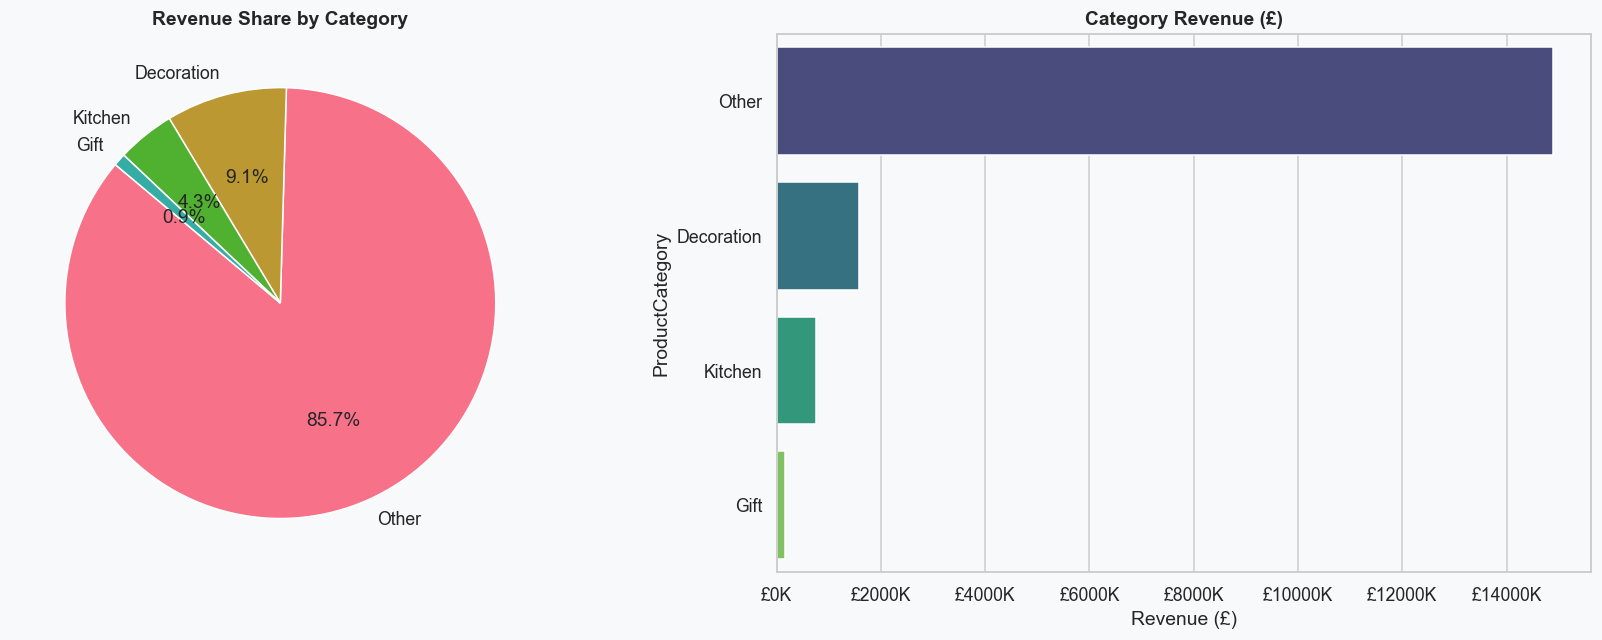

In [15]:
# ── 6.2 Revenue share by product category ────────────────────────────────────
cat_rev = (
    df_sales.groupby('ProductCategory')['TotalValue']
    .sum()
    .sort_values(ascending=False)
)
cat_rev_pct = (cat_rev / cat_rev.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(cat_rev.values, labels=cat_rev.index,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white'})
axes[0].set_title('Revenue Share by Category', fontweight='bold')

sns.barplot(x=cat_rev.values, y=cat_rev.index, ax=axes[1], palette='viridis')
axes[1].set_title('Category Revenue (£)', fontweight='bold')
axes[1].set_xlabel('Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

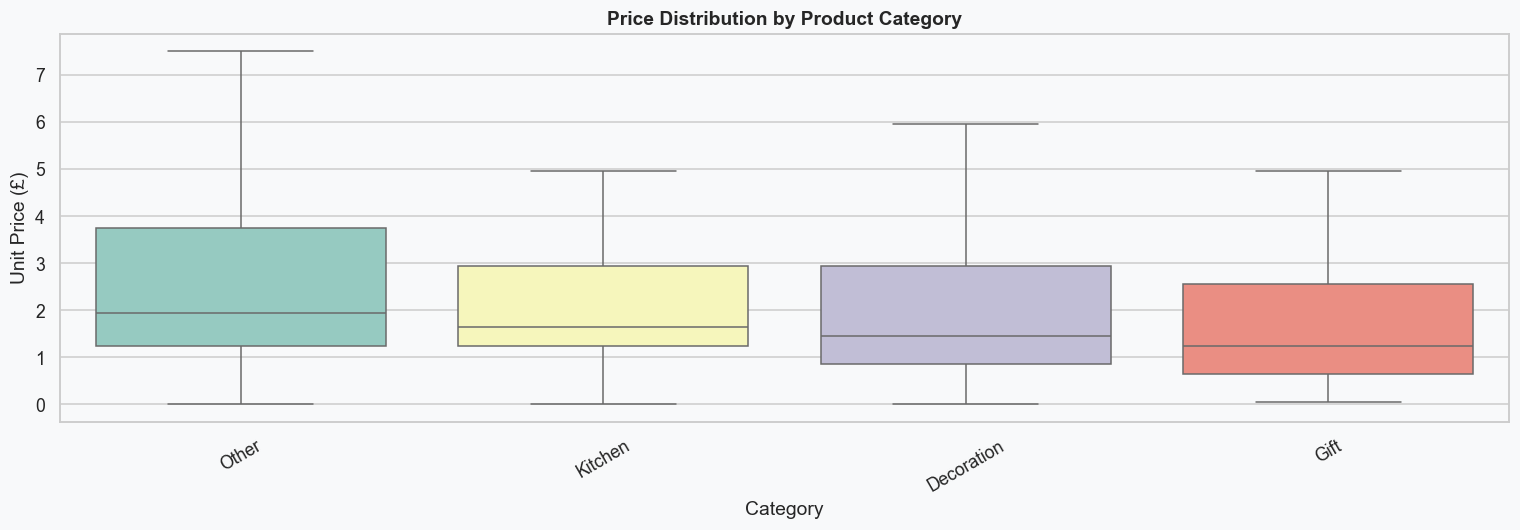

In [16]:
# ── 6.3 Price distribution by category (box plots) ───────────────────────────
# Filter extreme prices for readability
price_cap = df_sales['Price'].quantile(0.97)
df_plot   = df_sales[df_sales['Price'] <= price_cap]

fig, ax = plt.subplots(figsize=(14, 5))
order = df_plot.groupby('ProductCategory')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_plot, x='ProductCategory', y='Price', order=order,
            palette='Set3', ax=ax, showfliers=False)
ax.set_title('Price Distribution by Product Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Unit Price (£)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## 7. Phân tích địa lý (Geographic Analysis)

In [17]:
# ── 7.1 Country performance ───────────────────────────────────────────────────
country_stats = (
    df_sales.groupby('Country')
    .agg(
        Revenue         = ('TotalValue', 'sum'),
        Orders          = ('Invoice',    'nunique'),
        Customers       = ('Customer ID','nunique'),
    )
    .reset_index()
)
country_stats['AOV'] = country_stats['Revenue'] / country_stats['Orders']
country_stats = country_stats.sort_values('Revenue', ascending=False)

print('Top 15 Countries by Revenue:')
display(
    country_stats.head(15)
    .style
    .format({'Revenue': '£{:,.0f}', 'AOV': '£{:,.2f}', 'Orders': '{:,.0f}', 'Customers': '{:,.0f}'})
    .background_gradient(subset=['Revenue'], cmap='Blues')
)

Top 15 Countries by Revenue:


,Country,Revenue,Orders,Customers,AOV
38,United Kingdom,"£14,389,235","33,546","5,353",£428.94
10,EIRE,"£616,571",567,5,"£1,087.43"
24,Netherlands,"£554,038",229,22,"£2,419.38"
14,Germany,"£425,020",789,107,£538.68
13,France,"£348,769",614,95,£568.03
0,Australia,"£169,283",95,15,"£1,781.93"
32,Spain,"£108,332",154,41,£703.46
34,Switzerland,"£100,062",90,22,"£1,111.80"
33,Sweden,"£91,516",104,19,£879.96
9,Denmark,"£68,581",43,12,"£1,594.90"


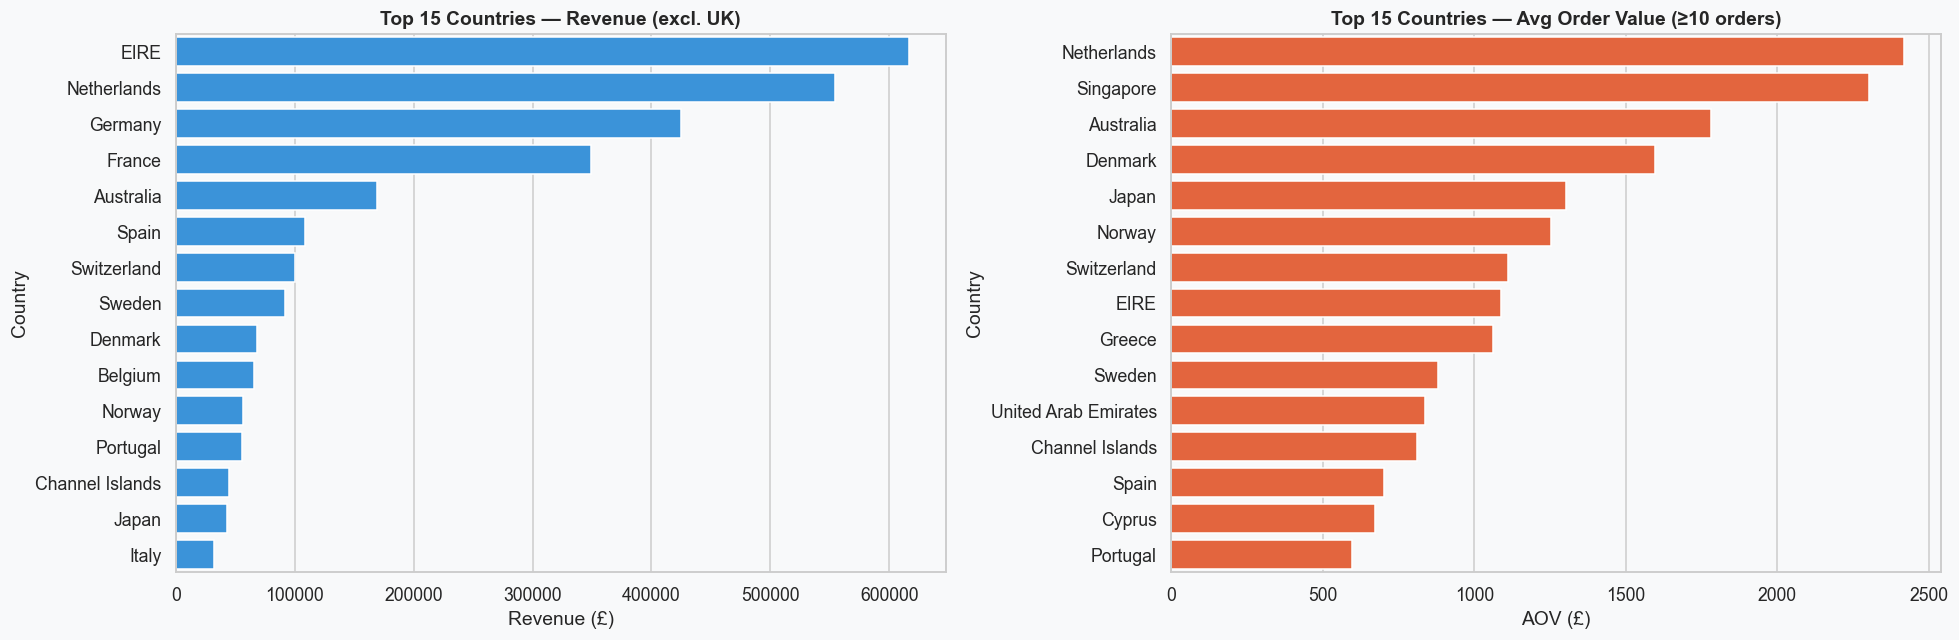

In [18]:
# ── 7.2 Geographic bar charts (exclude UK for scale) ─────────────────────────
top_excl_uk = country_stats[country_stats['Country'] != 'United Kingdom'].head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=top_excl_uk, x='Revenue', y='Country', ax=axes[0], color=ACCENT)
axes[0].set_title('Top 15 Countries — Revenue (excl. UK)', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')

top_aov = country_stats[country_stats['Orders'] >= 10].nlargest(15, 'AOV')
sns.barplot(data=top_aov, x='AOV', y='Country', ax=axes[1], color=ACCENT2)
axes[1].set_title('Top 15 Countries — Avg Order Value (≥10 orders)', fontweight='bold')
axes[1].set_xlabel('AOV (£)')

plt.tight_layout()
plt.show()

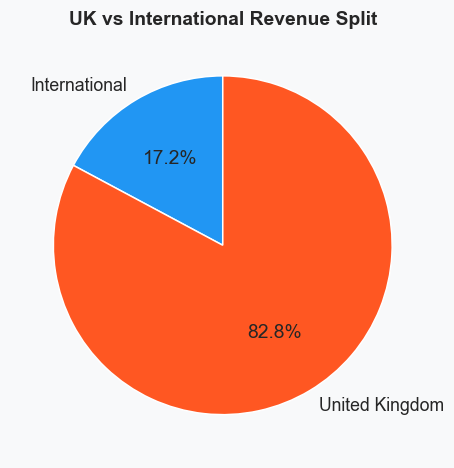

  International       : £2,985,569.35  (17.2%)
  United Kingdom      : £14,389,234.92  (82.8%)


In [19]:
# ── 7.3 UK vs International revenue split ────────────────────────────────────
df_sales['Region'] = df_sales['Country'].apply(
    lambda c: 'United Kingdom' if c == 'United Kingdom' else 'International'
)
region_rev = df_sales.groupby('Region')['TotalValue'].sum()

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(region_rev.values, labels=region_rev.index,
       autopct='%1.1f%%', colors=[ACCENT, ACCENT2],
       startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title('UK vs International Revenue Split', fontweight='bold')
plt.show()

for r, v in region_rev.items():
    print(f'  {r:<20}: £{v:>12,.2f}  ({v/region_rev.sum()*100:.1f}%)')

---
## 8. Phân tích hàng trả (Returns Analysis)

In [20]:
# ── 8.1 Return metrics ────────────────────────────────────────────────────────
ret_rev    = abs(df_returns['TotalValue'].sum())
sales_rev  = df_sales['TotalValue'].sum()
ret_pct    = ret_rev / sales_rev * 100

print(f'Total Returns Value : £{ret_rev:>12,.2f}')
print(f'Gross Sales Value   : £{sales_rev:>12,.2f}')
print(f'Return Rate (value) : {ret_pct:>11.2f}%')
print(f'Return Rows         : {len(df_returns):>12,}  ({len(df_returns)/len(df)*100:.2f}% of rows)')

Total Returns Value : £1,084,812.98
Gross Sales Value   : £17,374,804.27
Return Rate (value) :        6.24%
Return Rows         :       18,390  (2.30% of rows)


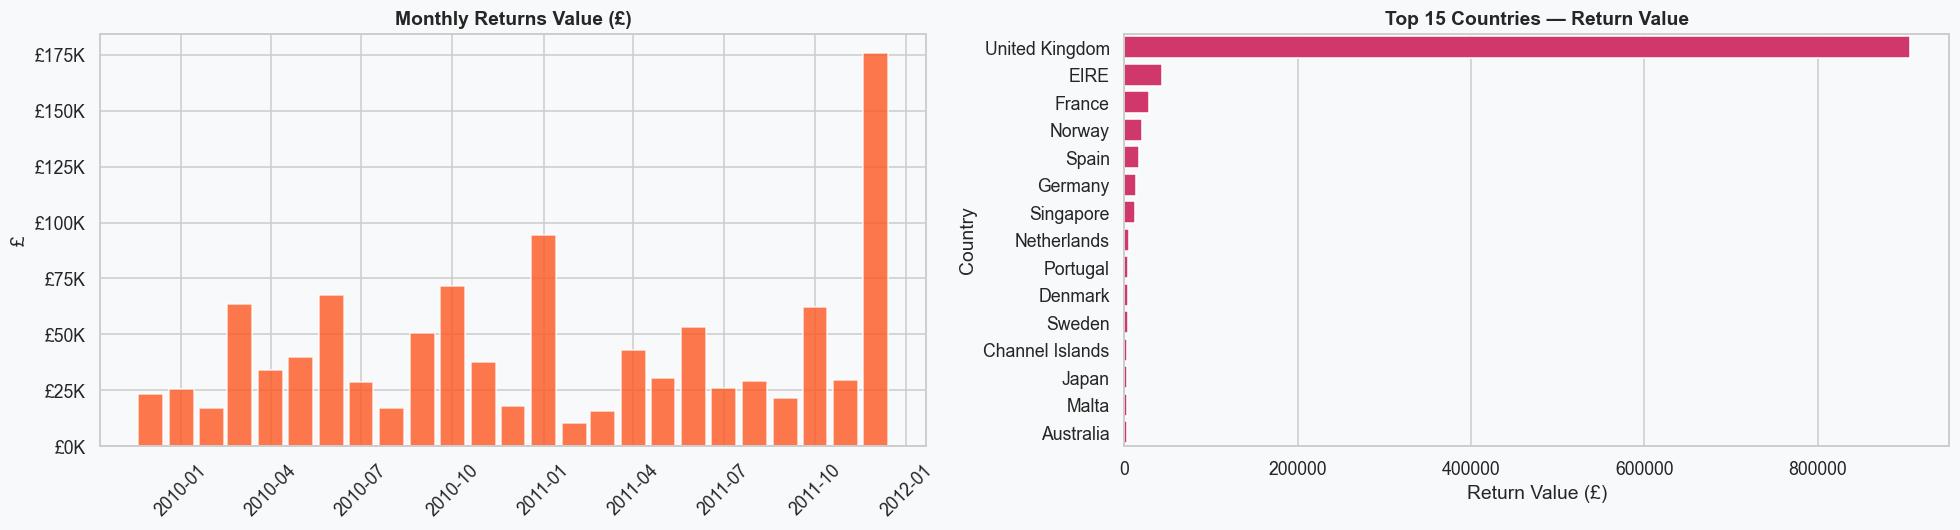

In [21]:
# ── 8.2 Returns over time & by country ───────────────────────────────────────
monthly_returns = (
    df_returns.groupby(['Year','Month'])
    .agg(ReturnValue=('TotalValue','sum'), ReturnRows=('Invoice','count'))
    .reset_index()
)
monthly_returns['ReturnValue'] = monthly_returns['ReturnValue'].abs()
monthly_returns['Date'] = pd.to_datetime(monthly_returns[['Year','Month']].assign(day=1))

country_returns = (
    df_returns.groupby('Country')['TotalValue']
    .sum().abs()
    .sort_values(ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(monthly_returns['Date'], monthly_returns['ReturnValue'], width=25, color=ACCENT2, alpha=0.8)
axes[0].set_title('Monthly Returns Value (£)', fontweight='bold')
axes[0].set_ylabel('£')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=country_returns.values, y=country_returns.index, ax=axes[1], color='#E91E63')
axes[1].set_title('Top 15 Countries — Return Value', fontweight='bold')
axes[1].set_xlabel('Return Value (£)')

plt.tight_layout()
plt.show()

---
## 9. Cohort Preview

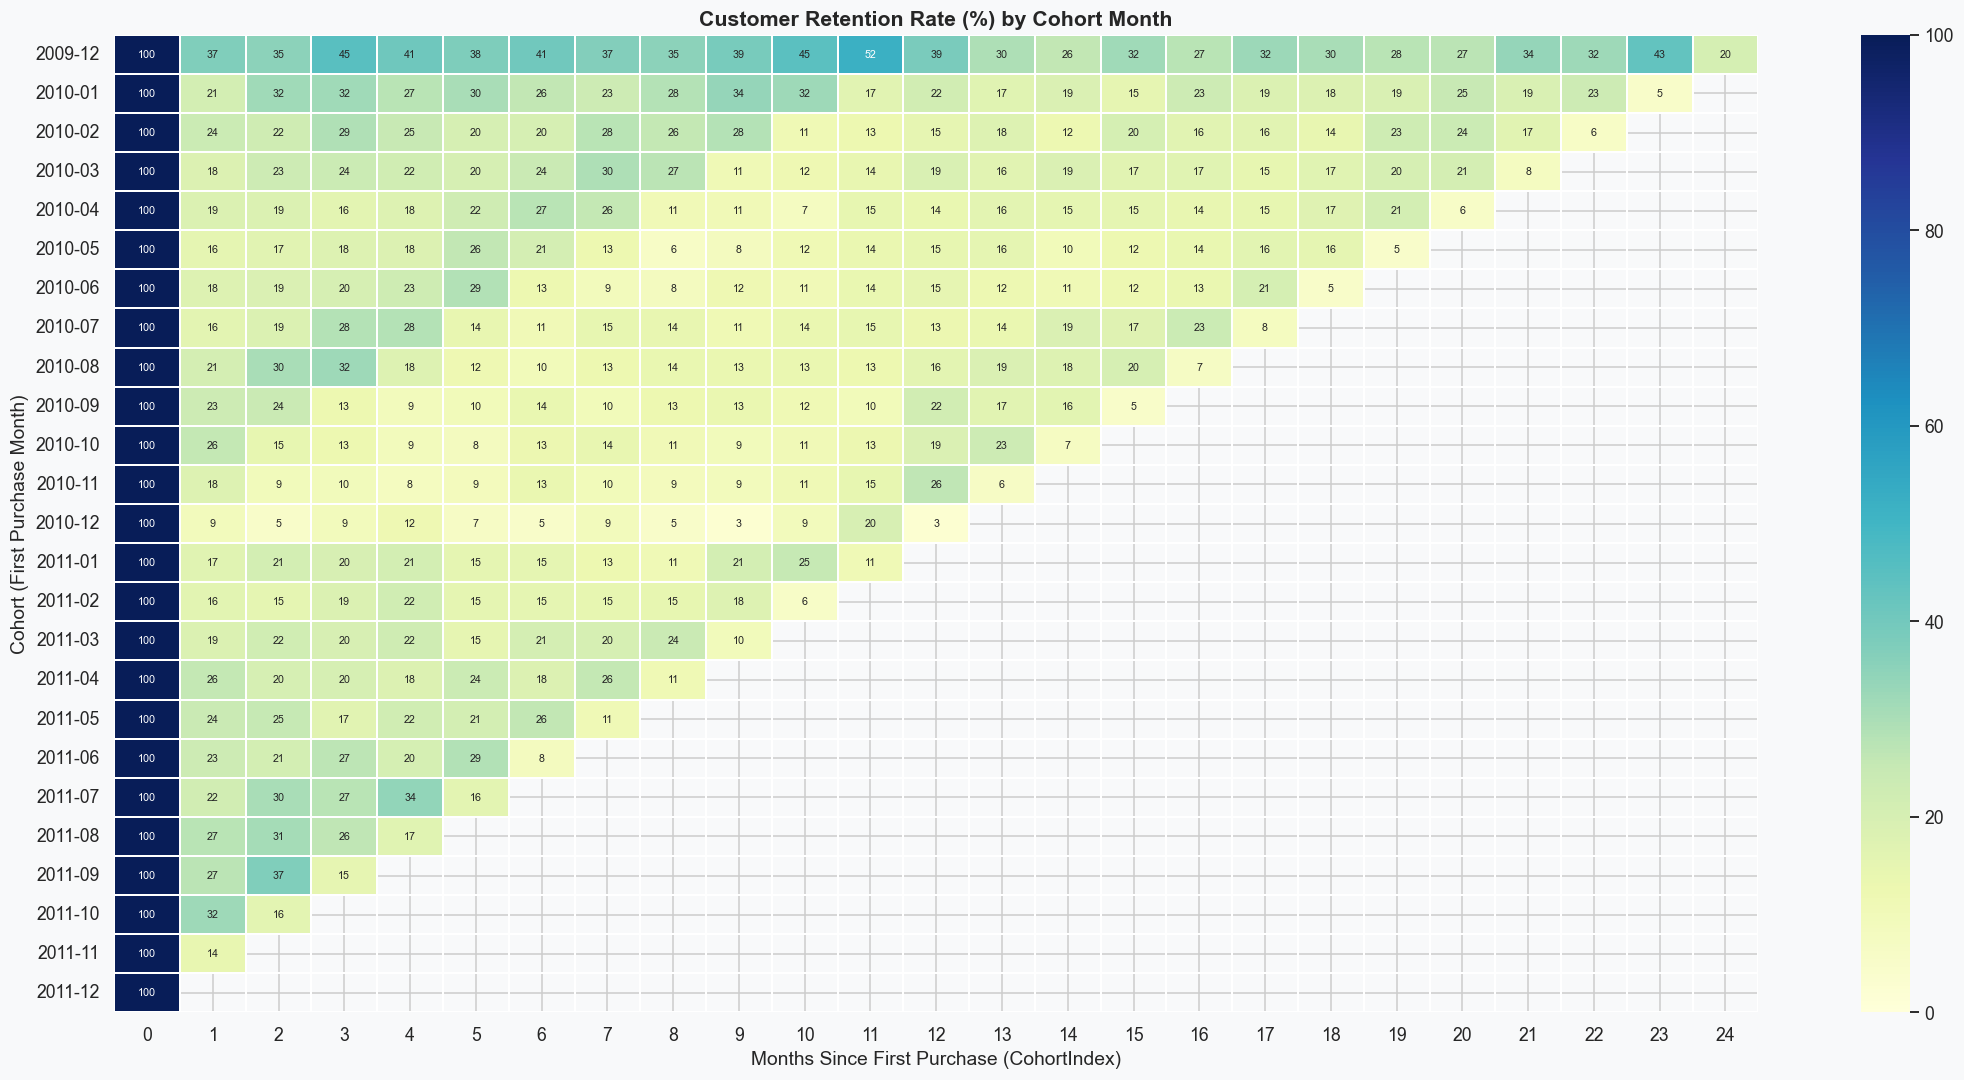


Average Retention Rate by Period:
CohortIndex
0    100.00
1     21.30
2     22.10
3     21.80
4     20.70
5     19.00
6     18.00
7     17.80
8     15.80
9     15.70
10    15.40
11    16.70
12    18.20


In [22]:
# ── 9.1 Cohort retention heatmap ──────────────────────────────────────────────
cohort_table = (
    df_sales.groupby(['CohortMonthYear','CohortIndex'])['Customer ID']
    .nunique()
    .unstack('CohortIndex')
)

# Retention rate relative to cohort size
cohort_size   = cohort_table.iloc[:, 0]
retention_pct = cohort_table.divide(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    retention_pct,
    annot=True, fmt='.0f', cmap='YlGnBu',
    linewidths=0.3, ax=ax, annot_kws={'size': 7},
    vmin=0, vmax=100
)
ax.set_title('Customer Retention Rate (%) by Cohort Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase (CohortIndex)')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

# Average retention across all cohorts
avg_retention = retention_pct.mean().round(1)
print('\nAverage Retention Rate by Period:')
print(avg_retention.head(13).to_string())

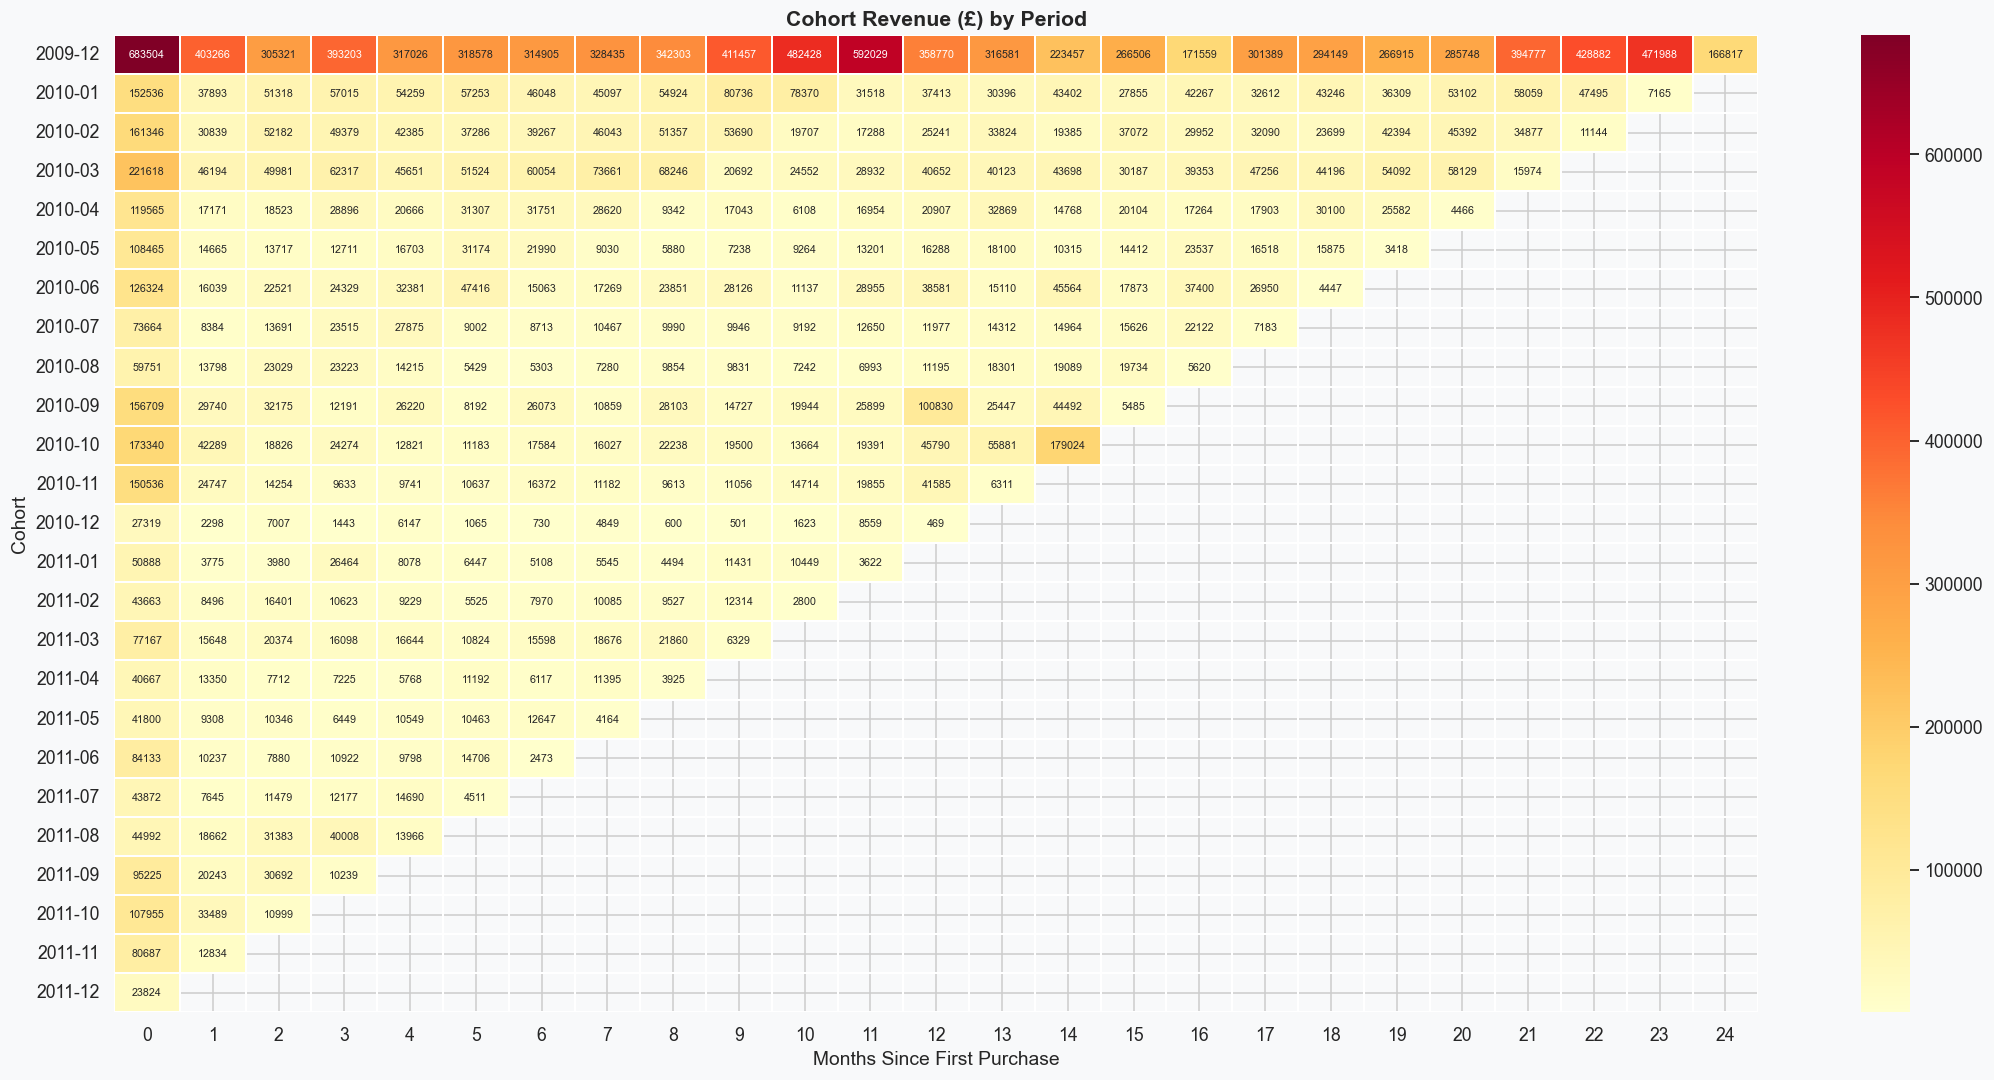

In [23]:
# ── 9.2 Cohort revenue heatmap ────────────────────────────────────────────────
cohort_rev = (
    df_sales.groupby(['CohortMonthYear','CohortIndex'])['TotalValue']
    .sum()
    .unstack('CohortIndex')
)

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    cohort_rev,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.3, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Cohort Revenue (£) by Period', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort')
plt.tight_layout()
plt.show()

---
## 10. Correlation Analysis & Key Insights

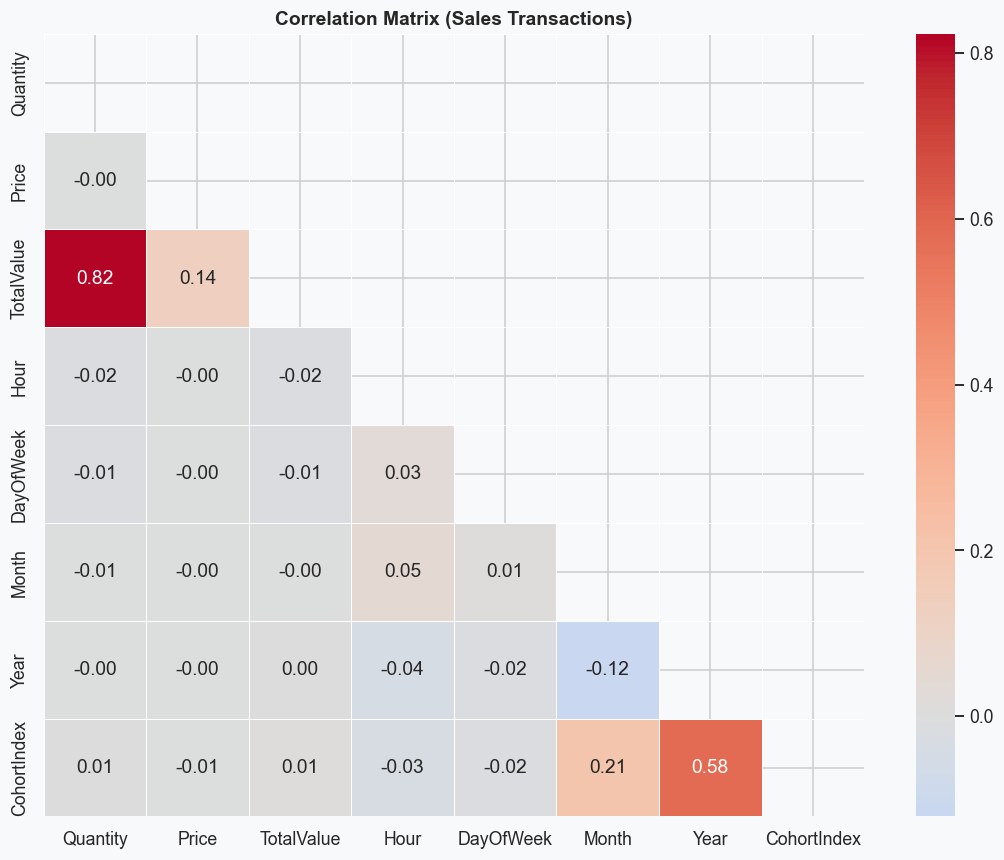

In [24]:
# ── 10.1 Correlation matrix ──────────────────────────────────────────────────
numeric_cols = ['Quantity','Price','TotalValue','Hour','DayOfWeek','Month','Year','CohortIndex']
corr = df_sales[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Sales Transactions)', fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# ── 10.2 Summary of Key Insights ─────────────────────────────────────────────
print('=' * 65)
print('  KEY EDA INSIGHTS')
print('=' * 65)

# Revenue
print(f'\n📦 REVENUE')
print(f'   Gross Revenue   : £{df_sales["TotalValue"].sum():>12,.0f}')
print(f'   Net Revenue     : £{df_sales["TotalValue"].sum() - abs(df_returns["TotalValue"].sum()):>12,.0f}')
print(f'   Avg Order Value : £{df_sales["TotalValue"].sum()/df_sales["Invoice"].nunique():>12,.2f}')

# Best month
best_month = monthly['TotalValue'].idxmax()
best_val   = monthly.loc[best_month, 'TotalValue']
best_label = monthly.loc[best_month, 'Date'].strftime('%b %Y')
print(f'\n📅 TIME PATTERNS')
print(f'   Best month      : {best_label} → £{best_val:,.0f}')
print(f'   Peak weekday    : {dow_rev.idxmax()} (£{dow_rev.max():,.0f})')
print(f'   Peak hour       : {hour_rev.idxmax()}:00  (£{hour_rev.max():,.0f})')

# Customers
champions   = rfm[rfm['Segment']=='Champions']
champion_pct= len(champions)/len(rfm)*100
print(f'\n👥 CUSTOMERS')
print(f'   Total customers : {len(rfm):>12,}')
print(f'   Champions (5/5) : {len(champions):>12,}  ({champion_pct:.1f}%)')
print(f'   Avg recency     : {rfm["Recency"].mean():>11.0f}d')
print(f'   Avg frequency   : {rfm["Frequency"].mean():>11.1f} orders')
print(f'   Avg monetary    : £{rfm["Monetary"].mean():>11,.2f}')

# Products
top_product = top20_rev.iloc[0]
print(f'\n🛍  PRODUCTS')
print(f'   Unique products : {df_sales["StockCode"].nunique():>12,}')
print(f'   Top product     : {top_product["Description"]}')
print(f'   Top revenue     : £{top_product["TotalRevenue"]:>10,.2f}')

# Geography
uk_rev  = country_stats[country_stats['Country']=='United Kingdom']['Revenue'].values[0]
all_rev = country_stats['Revenue'].sum()
print(f'\n🌍 GEOGRAPHY')
print(f'   UK revenue share: {uk_rev/all_rev*100:.1f}%')
print(f'   Countries served: {df_sales["Country"].nunique()}')
print(f'   Top intl market : {country_stats[country_stats["Country"]!="United Kingdom"].iloc[0]["Country"]}')

print('\n' + '=' * 65)

  KEY EDA INSIGHTS

📦 REVENUE
   Gross Revenue   : £  17,374,804
   Net Revenue     : £  16,289,991
   Avg Order Value : £      469.91

📅 TIME PATTERNS
   Best month      : Nov 2010 → £1,166,460
   Peak weekday    : Thursday (£3,745,783)
   Peak hour       : 12:00  (£2,690,584)

👥 CUSTOMERS
   Total customers :        5,881
   Champions (5/5) :        1,482  (25.2%)
   Avg recency     :         201d
   Avg frequency   :         6.3 orders
   Avg monetary    : £   2,954.40

🛍  PRODUCTS
   Unique products :        4,631
   Top product     : REGENCY CAKESTAND 3 TIER
   Top revenue     : £277,656.25

🌍 GEOGRAPHY
   UK revenue share: 82.8%
   Countries served: 41
   Top intl market : EIRE

